# Phase 4 — Malaria Stage Classifier
**Ring / Trophozoite / Schizont / Gametocyte** · EfficientNet-B0

| Dataset | Type | Annotation | Species |
|---------|------|------------|---------|
| MP-IDB | 210 full-slide PNG | GT mask + stage in filename | 4 |
| IML-Malaria | 345 full-slide JPG | JSON bounding-boxes | 1 (vivax) |
| MD-2019 | Pre-cropped PNG + XLSX | XLSX manifest (filename · label) | 1 (falciparum) |


## 1 · Install
> ⚠️ After this cell finishes: **Runtime → Restart session**, then run from cell 2.

In [1]:
!pip install -q torch torchvision scikit-learn matplotlib Pillow tqdm scipy numpy openpyxl
print("Done. Restart the runtime now.")


Done. Restart the runtime now.


## 2 · Imports

In [2]:
import os, json, random, glob, subprocess
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from scipy import ndimage
import openpyxl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("Imports OK | PyTorch", torch.__version__)


Imports OK | PyTorch 2.11.0+cu128


## 3 · Configuration
Edit **only this cell**.

In [3]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
SEED            = 42
EPOCHS_HEAD     = 6      # frozen backbone
EPOCHS_FINETUNE = 8      # full fine-tune
LR_HEAD         = 1e-3
LR_FT           = 1e-4
BACKBONE        = "efficientnet_b0"   # or "resnet18"

# ── Paths ─────────────────────────────────────────────────────────────────────
MPIDB_DIR  = "MP-IDB"
IML_DIR    = "IML"
MERGED_DIR = "./stage_merged"
ARTIFACTS  = "./artifacts"
CKPT       = os.path.join(ARTIFACTS, "stage_efficientnet_b0.pt")

os.makedirs(ARTIFACTS,  exist_ok=True)
os.makedirs(MERGED_DIR, exist_ok=True)

# ── MD-2019 (Mendeley — manual download) ──────────────────────────────────────
# Download: https://data.mendeley.com/datasets/5bf2kmwvfn/1
# Upload zip to Google Drive, extract it, then fill the two paths below.
# Leave as None to skip (notebook still trains on MP-IDB + IML).
MD2019_DIR  = "/content/drive/MyDrive/MD_2019/Giesma stained images"
MD2019_XLSX = "/content/drive/MyDrive/MD_2019/LifeStages.xlsx"

# ── Balancing: oversample minorities up to this count ─────────────────────────
OVERSAMPLE_TARGET = 1000   # minority classes will be duplicated up to this count
# Ring will be capped at OVERSAMPLE_TARGET too (undersampled if larger)
BALANCE_CAP = OVERSAMPLE_TARGET

# ── Stage vocabulary ──────────────────────────────────────────────────────────
STAGE_LONG     = {"R":"ring","T":"trophozoite","S":"schizont","G":"gametocyte"}
PARASITE_TYPES = set(STAGE_LONG.values())

MD2019_LABEL_MAP = {
    "R":    "ring",
    "LR-ET":"trophozoite",
    "MT":   "trophozoite",
    "LT":   "trophozoite",
    "Esch": "schizont",
    "Lsch": "schizont",
    "Seg":  "schizont",
}

COLORS = {"gametocyte":"#1D9E75","ring":"#378ADD",
          "schizont":"#BA7517","trophozoite":"#D4537E"}

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 4 · Mount Drive & Clone datasets

In [4]:
# Mount Google Drive (needed for MD-2019)
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [8]:
# Unzip MD-2019 if still zipped
zip_path   = "/content/drive/MyDrive/MD_2019.zip"
extract_to = "/content/drive/MyDrive/"
if os.path.exists(zip_path) and not os.path.isdir(MD2019_DIR or ""):
    print("Unzipping MD-2019 ...")
    r = subprocess.run(["unzip", "-q", zip_path, "-d", extract_to])
    # exit code 1 = warnings only (duplicate files, Drive permissions) — safe to ignore
    # exit code 2+ = real failure
    if r.returncode > 1:
        raise RuntimeError(f"unzip failed with exit code {r.returncode}")
    print("Done.")
else:
    print("MD-2019 zip not found or already extracted — skipping.")


Unzipping MD-2019 ...
Done.


In [9]:
def git_clone(url: str, dest: str) -> None:
    if os.path.isdir(dest):
        print(f"  {dest} already present."); return
    print(f"Cloning {url} ...")
    r = subprocess.run(["git","clone","--depth","1",url,dest],
                       capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{r.stderr[-400:]}")
    print(f"  -> {dest}")

git_clone(
    "https://github.com/andrealoddo/MP-IDB-The-Malaria-Parasite-Image-Database-for-Image-Processing-and-Analysis.git",
    MPIDB_DIR)
git_clone(
    "https://github.com/QaziAmmar/A-Dataset-and-Benchmark-for-Malaria-Life-Cycle-Classification-in-Thin-Blood-Smear-Images.git",
    IML_DIR)

assert os.path.isdir(MPIDB_DIR), f"MP-IDB not found at {MPIDB_DIR}"
assert os.path.isdir(IML_DIR),   f"IML not found at {IML_DIR}"
print("Repositories ready.")


Cloning https://github.com/andrealoddo/MP-IDB-The-Malaria-Parasite-Image-Database-for-Image-Processing-and-Analysis.git ...
  -> MP-IDB
Cloning https://github.com/QaziAmmar/A-Dataset-and-Benchmark-for-Malaria-Life-Cycle-Classification-in-Thin-Blood-Smear-Images.git ...
  -> IML
Repositories ready.


## 5 · Build merged dataset
Parsing all three sources → `stage_merged/<stage>/`

In [10]:
for stage in PARASITE_TYPES:
    os.makedirs(os.path.join(MERGED_DIR, stage), exist_ok=True)

_counters = {s: 0 for s in PARASITE_TYPES}

def save_crop(img: Image.Image, stage: str, tag: str) -> bool:
    if stage not in PARASITE_TYPES: return False
    w, h = img.size
    if w < 8 or h < 8: return False
    _counters[stage] += 1
    img.convert("RGB").save(
        os.path.join(MERGED_DIR, stage, f"{tag}_{_counters[stage]:06d}.jpg"),
        quality=95)
    return True


In [11]:
# ── Source A: MP-IDB ──────────────────────────────────────────────────────────
mpidb_added = 0
for sp in ["Falciparum","Vivax","Malariae","Ovale"]:
    sp_dir    = os.path.join(MPIDB_DIR, sp)
    crop_base = os.path.join(sp_dir, "crops")

    if os.path.isdir(crop_base):            # pre-made crops (Falciparum, Vivax)
        for code, stage in STAGE_LONG.items():
            cd = os.path.join(crop_base, code)
            if not os.path.isdir(cd): continue
            for f in os.listdir(cd):
                if not f.lower().endswith((".png",".jpg",".jpeg")): continue
                try:
                    if save_crop(Image.open(os.path.join(cd,f)), stage, f"mpidb_{sp.lower()}"):
                        mpidb_added += 1
                except Exception: pass
        continue

    img_dir = os.path.join(sp_dir,"img"); gt_dir = os.path.join(sp_dir,"gt")
    if not (os.path.isdir(img_dir) and os.path.isdir(gt_dir)): continue

    for gt_fname in tqdm(sorted(os.listdir(gt_dir)), desc=f"MP-IDB {sp}"):
        if not gt_fname.lower().endswith((".jpg",".png")): continue
        stem  = os.path.splitext(gt_fname)[0]
        codes = [c for c in stem.split("-")[-1].split("_") if c in STAGE_LONG]
        if len(codes) != 1: continue
        stage    = STAGE_LONG[codes[0]]
        img_path = os.path.join(img_dir, gt_fname)
        gt_path  = os.path.join(gt_dir,  gt_fname)
        if not (os.path.exists(img_path) and os.path.exists(gt_path)): continue
        try:
            img_arr = np.array(Image.open(img_path).convert("RGB"))
            gt_arr  = np.array(Image.open(gt_path).convert("L"))
        except Exception: continue
        labeled, n = ndimage.label(gt_arr > 128)
        for bid in range(1, n+1):
            bm   = labeled == bid
            rows = np.where(bm.any(axis=1))[0]
            cols = np.where(bm.any(axis=0))[0]
            if not len(rows) or not len(cols): continue
            p    = 10
            r0   = max(0, int(rows[0])-p);  r1 = min(img_arr.shape[0], int(rows[-1])+p)
            c0   = max(0, int(cols[0])-p);  c1 = min(img_arr.shape[1], int(cols[-1])+p)
            if save_crop(Image.fromarray(img_arr[r0:r1,c0:c1]), stage, f"mpidb_{sp.lower()}"):
                mpidb_added += 1

print(f"MP-IDB  : {mpidb_added:4d} crops")


MP-IDB Malariae:   0%|          | 0/37 [00:00<?, ?it/s]

MP-IDB Ovale:   0%|          | 0/29 [00:00<?, ?it/s]

MP-IDB  : 1426 crops


In [12]:
# ── Source B: IML-Malaria ─────────────────────────────────────────────────────
IML_IMG_DIR  = os.path.join(IML_DIR,"IML_Malaria")
IML_ANN_PATH = os.path.join(IML_DIR,"annotations.json")
assert os.path.isfile(IML_ANN_PATH), f"Not found: {IML_ANN_PATH}"

with open(IML_ANN_PATH,"r",encoding="utf-8") as f:
    iml_data = json.load(f)

iml_added = iml_skip = 0
for entry in tqdm(iml_data, desc="IML-Malaria"):
    ip = os.path.join(IML_IMG_DIR, entry["image_name"])
    if not os.path.exists(ip): iml_skip += 1; continue
    try:   full = Image.open(ip).convert("RGB")
    except Exception: iml_skip += 1; continue
    iw, ih = full.size
    for obj in entry.get("objects",[]):
        t = obj.get("type","")
        if t not in PARASITE_TYPES: continue
        b = obj.get("bbox",{})
        try:
            x,y,w,h = (int(float(b[k])) for k in ("x","y","w","h"))
        except Exception: continue
        x0,y0 = max(0,x), max(0,y)
        x1,y1 = min(iw,x+w), min(ih,y+h)
        if x1<=x0 or y1<=y0: continue
        if save_crop(full.crop((x0,y0,x1,y1)), t, "iml"):
            iml_added += 1

print(f"IML     : {iml_added:4d} crops  ({iml_skip} images skipped)")


IML-Malaria:   0%|          | 0/345 [00:00<?, ?it/s]

IML     :  529 crops  (0 images skipped)


In [13]:
# ── Source C: MD-2019 ─────────────────────────────────────────────────────────
md_added = md_skip = md_unk = 0

if MD2019_DIR and MD2019_XLSX:
    if not os.path.isdir(MD2019_DIR):
        print(f"MD2019_DIR not found: {MD2019_DIR} — skipped.")
    elif not os.path.isfile(MD2019_XLSX):
        print(f"MD2019_XLSX not found: {MD2019_XLSX} — skipped.")
    else:
        wb = openpyxl.load_workbook(MD2019_XLSX, read_only=True, data_only=True)
        ws = wb.active
        for row in tqdm(ws.iter_rows(min_row=2, values_only=True), desc="MD-2019"):
            if not row or row[1] is None: continue
            fname     = str(row[1]).strip()
            raw_label = str(row[2]).strip() if row[2] is not None else ""
            stage = MD2019_LABEL_MAP.get(raw_label)
            if stage is None: md_unk += 1; continue
            ip = os.path.join(MD2019_DIR, fname)
            if not os.path.exists(ip): md_skip += 1; continue
            try:
                if save_crop(Image.open(ip), stage, "md2019"):
                    md_added += 1
            except Exception: md_skip += 1
        wb.close()
        print(f"MD-2019 : {md_added:4d} crops  ({md_skip} missing, {md_unk} non-parasite rows skipped)")
else:
    print("MD-2019 skipped (paths not set).")

print()
print("── Raw merged totals ─────────────────")
total = 0
for s in sorted(PARASITE_TYPES):
    n = len(os.listdir(os.path.join(MERGED_DIR, s)))
    total += n
    print(f"  {s:14s}  {n:5d}")
print(f"  {'TOTAL':14s}  {total:5d}")


MD2019_DIR not found: /content/drive/MyDrive/MD_2019/Giesma stained images — skipped.

── Raw merged totals ─────────────────
  gametocyte        290
  ring             1444
  schizont           67
  trophozoite       154
  TOTAL            1955


## 6 · Explore the data

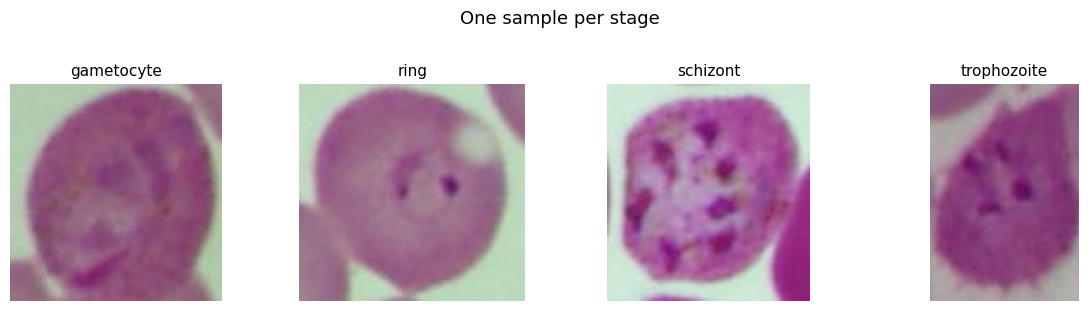

In [33]:
# ── 6a. Sample image per class ────────────────────────────────────────────────
base_tmp = datasets.ImageFolder(MERGED_DIR)
CLASSES  = base_tmp.classes   # set here so visualisation works before split

fig, axes = plt.subplots(1, len(CLASSES), figsize=(3*len(CLASSES), 3))
for ax, cls in zip(axes, CLASSES):
    cls_dir = os.path.join(MERGED_DIR, cls)
    files   = [f for f in os.listdir(cls_dir)
               if f.lower().endswith((".jpg",".png",".jpeg"))]
    if files:
        ax.imshow(Image.open(os.path.join(cls_dir, random.choice(files))))
    ax.set_title(cls, fontsize=11)
    ax.axis("off")
plt.suptitle("One sample per stage", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


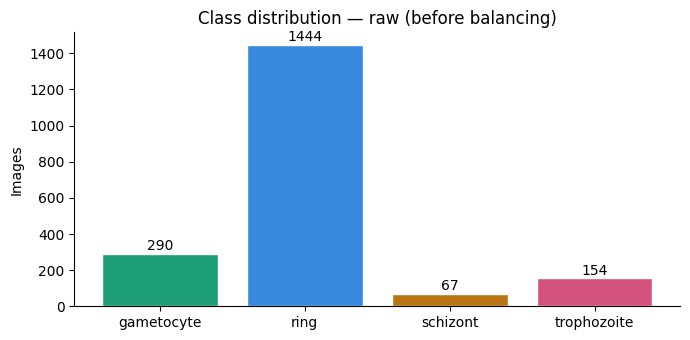

Imbalance ratio (max/min): 21.6


In [15]:
# ── 6b. Raw class distribution ────────────────────────────────────────────────
raw_counts = np.array([len(os.listdir(os.path.join(MERGED_DIR,c))) for c in CLASSES])
color_list = [COLORS[c] for c in CLASSES]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(CLASSES, raw_counts, color=color_list, edgecolor="white")
for bar, cnt in zip(bars, raw_counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(cnt), ha="center", va="bottom", fontsize=10)
ax.set_title("Class distribution — raw (before balancing)")
ax.set_ylabel("Images"); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("Imbalance ratio (max/min):", round(raw_counts.max()/max(raw_counts.min(),1), 1))


## 7 · Balance the dataset

Three complementary strategies applied together:
1. **Undersample ring** (cap at `BALANCE_CAP`)
2. **Oversample minorities** (duplicate indices up to `OVERSAMPLE_TARGET`)
3. **WeightedRandomSampler** (ensure balanced batches)
4. **Class-weighted loss** (penalise mistakes on rare classes more)

In [16]:
# ── Build base dataset + stratified split ─────────────────────────────────────
base    = datasets.ImageFolder(MERGED_DIR)
CLASSES = base.classes
targets = np.array([lbl for _, lbl in base.samples])

idx = np.arange(len(targets))
tv_idx,  test_idx = train_test_split(idx,    test_size=0.15, stratify=targets,         random_state=SEED)
tr_idx,  val_idx  = train_test_split(tv_idx, test_size=0.1765, stratify=targets[tv_idx], random_state=SEED)

print("Split sizes — train:", len(tr_idx), "| val:", len(val_idx), "| test:", len(test_idx))
print("Per-class (train, raw):", dict(zip(CLASSES, np.bincount(targets[tr_idx], minlength=len(CLASSES)))))


Split sizes — train: 1367 | val: 294 | test: 294
Per-class (train, raw): {'gametocyte': np.int64(202), 'ring': np.int64(1010), 'schizont': np.int64(47), 'trophozoite': np.int64(108)}


In [17]:
# ── 7a. Undersample ring + oversample minorities ───────────────────────────────
set_seed()
c2i = base.class_to_idx
balanced_idx = []

for cls in CLASSES:
    ci      = c2i[cls]
    cls_idx = tr_idx[targets[tr_idx] == ci]   # all training indices for this class

    if cls == "ring":
        # cap ring
        if len(cls_idx) > BALANCE_CAP:
            cls_idx = np.random.choice(cls_idx, BALANCE_CAP, replace=False)
    else:
        # oversample minority up to OVERSAMPLE_TARGET
        if len(cls_idx) < OVERSAMPLE_TARGET:
            extra   = np.random.choice(cls_idx, OVERSAMPLE_TARGET - len(cls_idx), replace=True)
            cls_idx = np.concatenate([cls_idx, extra])

    balanced_idx.append(cls_idx)

tr_idx = np.concatenate(balanced_idx)
np.random.shuffle(tr_idx)

tr_counts = np.bincount(targets[tr_idx], minlength=len(CLASSES))
print("Per-class (train, after balancing):", dict(zip(CLASSES, tr_counts)))


Per-class (train, after balancing): {'gametocyte': np.int64(1000), 'ring': np.int64(1000), 'schizont': np.int64(1000), 'trophozoite': np.int64(1000)}


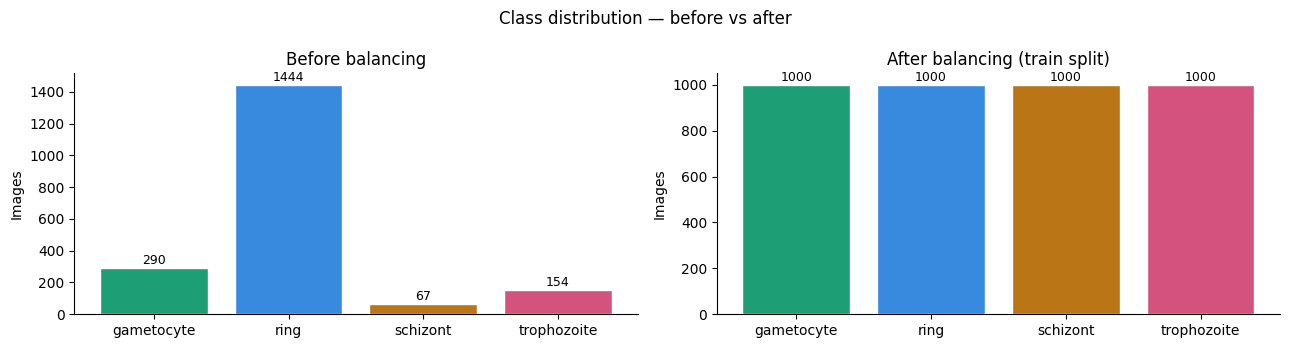

In [18]:
# ── 7b. Visualise distribution AFTER balancing ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Before
axes[0].bar(CLASSES, raw_counts, color=color_list, edgecolor="white")
for ax_b, cnt in zip(axes[0].patches, raw_counts):
    axes[0].text(ax_b.get_x()+ax_b.get_width()/2, ax_b.get_height()+5,
                 str(cnt), ha="center", va="bottom", fontsize=9)
axes[0].set_title("Before balancing"); axes[0].set_ylabel("Images")
axes[0].spines[["top","right"]].set_visible(False)

# After
axes[1].bar(CLASSES, tr_counts, color=color_list, edgecolor="white")
for ax_b, cnt in zip(axes[1].patches, tr_counts):
    axes[1].text(ax_b.get_x()+ax_b.get_width()/2, ax_b.get_height()+5,
                 str(cnt), ha="center", va="bottom", fontsize=9)
axes[1].set_title("After balancing (train split)"); axes[1].set_ylabel("Images")
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle("Class distribution — before vs after", fontsize=12)
plt.tight_layout(); plt.show()


## 8 · DataLoaders

In [19]:
# Transforms
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class SubsetDS(Dataset):
    def __init__(self, base_ds, indices, tf):
        self.base, self.indices, self.tf = base_ds, indices, tf
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        return self.tf(self.base.loader(path)), label

# WeightedRandomSampler on the already-balanced training set
w_per_cls    = 1.0 / np.clip(tr_counts, 1, None)
sample_w     = w_per_cls[targets[tr_idx]]
sampler      = WeightedRandomSampler(torch.as_tensor(sample_w, dtype=torch.double),
                                     len(tr_idx), replacement=True)

NW = 2   # set to 0 if Colab multiprocessing errors occur
train_loader = DataLoader(SubsetDS(base, tr_idx,   train_tf), BATCH_SIZE,
                          sampler=sampler, num_workers=NW, pin_memory=True)
val_loader   = DataLoader(SubsetDS(base, val_idx,  eval_tf),  BATCH_SIZE,
                          shuffle=False, num_workers=NW, pin_memory=True)
test_loader  = DataLoader(SubsetDS(base, test_idx, eval_tf),  BATCH_SIZE,
                          shuffle=False, num_workers=NW, pin_memory=True)

print(f"train {len(tr_idx)} | val {len(val_idx)} | test {len(test_idx)}")


train 4000 | val 294 | test 294


## 9 · Model — EfficientNet-B0

In [20]:
def build_model(backbone=BACKBONE, freeze=True):
    if backbone == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        if freeze:
            for p in m.parameters(): p.requires_grad = False
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(CLASSES))
    elif backbone == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        if freeze:
            for p in m.parameters(): p.requires_grad = False
        m.fc = nn.Linear(m.fc.in_features, len(CLASSES))
    else:
        raise ValueError(f"Unknown backbone: {backbone!r}")
    return m

model = build_model(freeze=True).to(device)

# Class-weighted loss (uses raw counts so weight reflects true rarity)
all_counts = np.bincount(targets, minlength=len(CLASSES))
cw = torch.tensor(all_counts.sum() / (len(CLASSES) * np.clip(all_counts,1,None)),
                  dtype=torch.float32, device=device)

print("Class weights:", dict(zip(CLASSES, cw.cpu().numpy().round(3))))
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 133MB/s]


Class weights: {'gametocyte': np.float32(1.685), 'ring': np.float32(0.338), 'schizont': np.float32(7.295), 'trophozoite': np.float32(3.174)}
Trainable params: 5124


## 10 · Train

In [21]:
def run_epoch(loader, is_train, criterion, optimizer=None):
    model.train() if is_train else model.eval()
    loss_sum = correct = total = 0
    with torch.set_grad_enabled(is_train):
        for x, y in tqdm(loader, leave=False):
            x, y = x.to(device), y.to(device)
            if is_train: optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            if is_train: loss.backward(); optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += x.size(0)
    return loss_sum / total, correct / total

def fit(epochs, lr, history, ckpt_path):
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                                 lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.3, patience=2)
    best_val = min(history["val_loss"]) if history["val_loss"] else float("inf")
    for _ in range(epochs):
        tl, ta = run_epoch(train_loader, True,  criterion, optimizer)
        vl, va = run_epoch(val_loader,   False, criterion)
        scheduler.step(vl)
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta);  history["val_acc"].append(va)
        ep = len(history["train_loss"])
        print(f"epoch {ep:02d} | train loss {tl:.4f} acc {ta:.4f} | val loss {vl:.4f} acc {va:.4f}")
        if vl < best_val:
            best_val = vl
            torch.save({"model_state":model.state_dict(),"classes":CLASSES,"backbone":BACKBONE}, ckpt_path)
            print(f"  ✓ checkpoint saved")
    return history


In [22]:
history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}

print("─"*55)
print(f"Phase A — head only  ({EPOCHS_HEAD} epochs, lr={LR_HEAD})")
print("─"*55)
history = fit(EPOCHS_HEAD, LR_HEAD, history, CKPT)

for p in model.parameters(): p.requires_grad = True

print()
print("─"*55)
print(f"Phase B — full fine-tune  ({EPOCHS_FINETUNE} epochs, lr={LR_FT})")
print("─"*55)
history = fit(EPOCHS_FINETUNE, LR_FT, history, CKPT)


───────────────────────────────────────────────────────
Phase A — head only  (6 epochs, lr=0.001)
───────────────────────────────────────────────────────


  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

epoch 01 | train loss 0.7431 acc 0.4718 | val loss 0.9541 acc 0.5272
  ✓ checkpoint saved


  0%|          | 0/125 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

epoch 13 | train loss 0.0545 acc 0.9427 | val loss 0.9851 acc 0.8503


  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

epoch 14 | train loss 0.0536 acc 0.9455 | val loss 0.9589 acc 0.8571


## 11 · Training curves

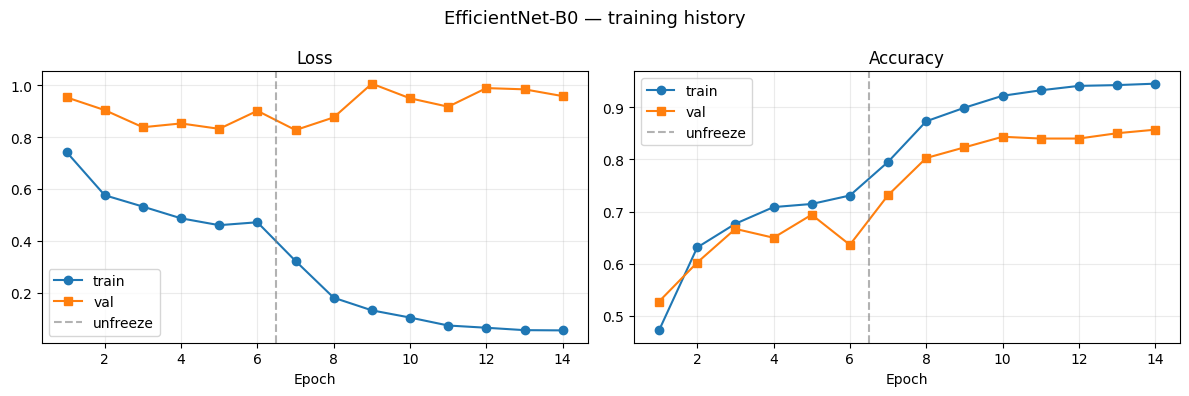

In [23]:
ep  = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (k_tr, k_val), title in zip(
    axes,
    [("train_loss","val_loss"), ("train_acc","val_acc")],
    ["Loss", "Accuracy"]
):
    ax.plot(ep, history[k_tr],  "o-", label="train", linewidth=1.5)
    ax.plot(ep, history[k_val], "s-", label="val",   linewidth=1.5)
    ax.axvline(EPOCHS_HEAD + 0.5, ls="--", color="gray", alpha=0.6, label="unfreeze")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.25)

plt.suptitle("EfficientNet-B0 — training history", fontsize=13)
plt.tight_layout(); plt.show()


## 12 · Evaluate on test set

In [24]:
ckpt = torch.load(CKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

y_true, y_pred, y_prob = [], [], []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing", leave=False):
        logits = model(x.to(device))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        y_prob.append(probs); y_pred.append(preds); y_true.append(y.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_prob = np.concatenate(y_prob)

acc        = accuracy_score(y_true, y_pred)
pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred,
                                                 average="macro", zero_division=0)
print(f"Accuracy   : {acc:.4f}")
print(f"Macro-P    : {pr:.4f}")
print(f"Macro-R    : {rc:.4f}")
print(f"Macro-F1   : {f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))


Testing:   0%|          | 0/10 [00:00<?, ?it/s]

Accuracy   : 0.7415
Macro-P    : 0.6485
Macro-R    : 0.8088
Macro-F1   : 0.6659

              precision    recall  f1-score   support

  gametocyte       0.92      0.77      0.84        44
        ring       0.97      0.72      0.83       217
    schizont       0.48      1.00      0.65        10
 trophozoite       0.23      0.74      0.35        23

    accuracy                           0.74       294
   macro avg       0.65      0.81      0.67       294
weighted avg       0.89      0.74      0.79       294



## 13 · Evaluation graphs

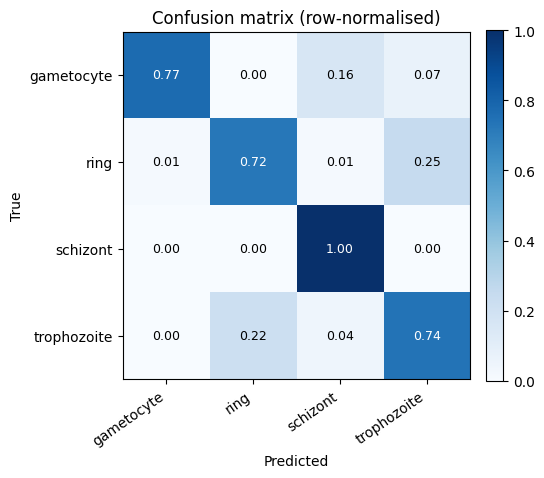

In [25]:
# ── 13a. Confusion matrix ─────────────────────────────────────────────────────
cm  = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)))
cmn = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=35, ha="right")
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix (row-normalised)")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if cmn[i,j] > 0.5 else "black")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


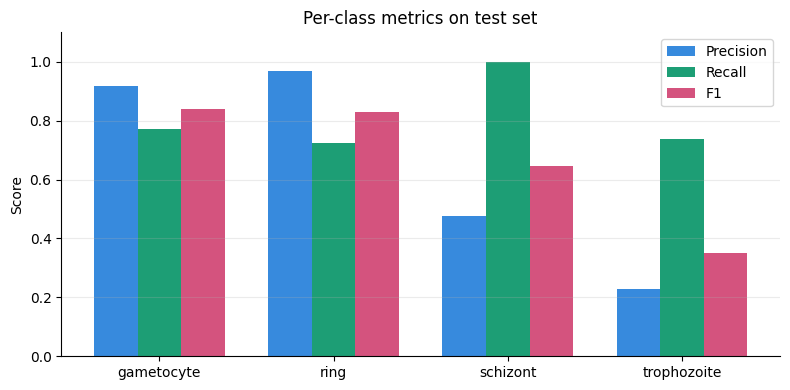

In [26]:
# ── 13b. Per-class precision / recall / F1 bar chart ─────────────────────────
pr_c, rc_c, f1_c, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None, zero_division=0)

x   = np.arange(len(CLASSES)); w = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w,   pr_c, w, label="Precision", color="#378ADD")
ax.bar(x,       rc_c, w, label="Recall",    color="#1D9E75")
ax.bar(x + w,   f1_c, w, label="F1",        color="#D4537E")
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
ax.set_title("Per-class metrics on test set")
ax.legend(); ax.grid(axis="y", alpha=0.25)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


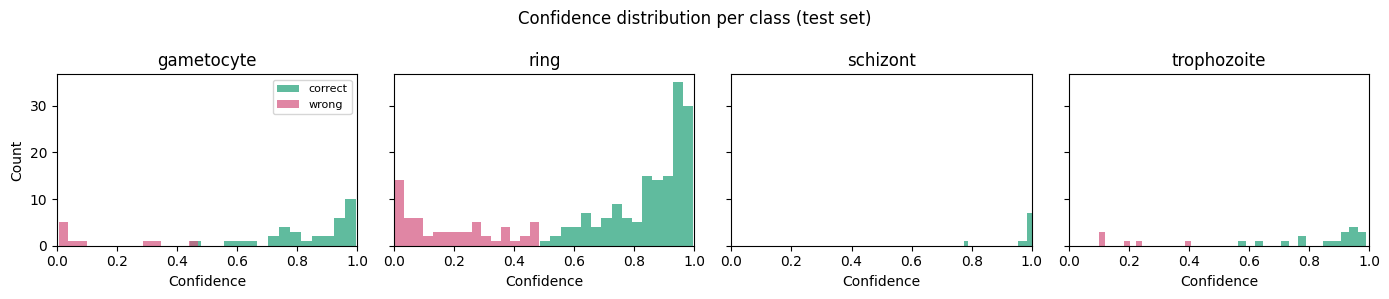

In [27]:
# ── 13c. Confidence distribution per class ────────────────────────────────────
fig, axes = plt.subplots(1, len(CLASSES), figsize=(3.5*len(CLASSES), 3), sharey=True)
for i, (ax, cls) in enumerate(zip(axes, CLASSES)):
    mask    = y_true == i
    correct = y_pred[mask] == i
    confs   = y_prob[mask, i]
    ax.hist(confs[correct],  bins=15, alpha=0.7, color="#1D9E75", label="correct")
    ax.hist(confs[~correct], bins=15, alpha=0.7, color="#D4537E", label="wrong")
    ax.set_title(cls); ax.set_xlabel("Confidence"); ax.set_xlim(0,1)
    if i == 0: ax.set_ylabel("Count"); ax.legend(fontsize=8)
plt.suptitle("Confidence distribution per class (test set)", fontsize=12)
plt.tight_layout(); plt.show()


## 14 · (Optional) Classify Phase-3 crops

In [28]:
crop_paths = sorted(glob.glob("./artifacts/parasite_crops/*.png"))[:6]
if crop_paths:
    model.eval()
    fig, axes = plt.subplots(1, len(crop_paths), figsize=(2.8*len(crop_paths), 3))
    axes = np.atleast_1d(axes)
    for ax, p in zip(axes, crop_paths):
        img = Image.open(p).convert("RGB")
        with torch.no_grad():
            prob = torch.softmax(model(eval_tf(img).unsqueeze(0).to(device)), dim=1)[0]
        k = int(prob.argmax())
        ax.imshow(img); ax.axis("off")
        ax.set_title(f"{CLASSES[k]}\n{prob[k]:.2f}", fontsize=9)
    plt.suptitle("Phase-3 crops → predicted stage")
    plt.tight_layout(); plt.show()
else:
    print("No Phase-3 crops at ./artifacts/parasite_crops/ — run Phase 3 first.")


No Phase-3 crops at ./artifacts/parasite_crops/ — run Phase 3 first.


## 15. Saving the modal

In [34]:
# ── Save to Google Drive ──────────────────────────────────────────────────────
DRIVE_SAVE_PATH = "/content/drive/MyDrive/phase4_stage_classifier.pt"

torch.save({
    "model_state": model.state_dict(),
    "classes":     CLASSES,
    "backbone":    BACKBONE,
    "img_size":    IMG_SIZE,
}, DRIVE_SAVE_PATH)

print(f"Model saved -> {DRIVE_SAVE_PATH}")

Model saved -> /content/drive/MyDrive/phase4_stage_classifier.pt


In [35]:
# ── Load back ─────────────────────────────────────────────────────────────────
DRIVE_SAVE_PATH = "/content/drive/MyDrive/phase4_stage_classifier.pt"

ckpt     = torch.load(DRIVE_SAVE_PATH, map_location=device, weights_only=False)
CLASSES  = ckpt["classes"]
IMG_SIZE = ckpt.get("img_size", 224)

model = build_model(backbone=ckpt["backbone"], freeze=False).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Model loaded. Classes:", CLASSES)

# ── Predict a single image ────────────────────────────────────────────────────
def predict(image_path: str) -> tuple:
    tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    img = Image.open(image_path).convert("RGB")
    with torch.no_grad():
        prob = torch.softmax(model(tf(img).unsqueeze(0).to(device)), dim=1)[0]
    k = int(prob.argmax())
    return CLASSES[k], float(prob[k])

# Usage:
# cls, conf = predict("/path/to/cell.png")
# print(f"{cls}  ({conf:.2%})")

Model loaded. Classes: ['gametocyte', 'ring', 'schizont', 'trophozoite']
